# Knn-Imputer

## The Deep Intuition: The Detective Algorithm
Imagine you are looking at a Titanic passenger manifest, and a passenger named "Arthur" is missing his Age.
- Mean/Median Imputation looks at Arthur, ignores absolutely everything else about him, and just assigns him the average age of the entire ship (let's say 28).

- KNN (K-Nearest Neighbors) Imputation acts like a detective. It looks at Arthur's other details. It sees he paid £500 for his ticket and is in 1st Class. The algorithm then scans the ship to find the $K$ (e.g., 5) passengers who are mathematically most similar to Arthur—other 1st Class passengers who paid around £500. It then averages their ages (which might be around 45) and assigns that to Arthur.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

# Approach of understanding
To prove how powerful this is in Colab, we need a dataset where Median imputation will fail spectacularly.

We will generate a company dataset with two very distinct groups: Junior Devs (Young, lower salary) and Senior Devs (Older, higher salary). If a Senior Dev is missing their age, guessing the "Median" of the whole company will drag their age way down. KNN will fix this.

In [2]:
np.random.seed(42)
# Cluster 1: Junior Devs (Age ~24, Salary ~60k)
juniors = pd.DataFrame({
    'Salary': np.random.normal(60000, 5000, 100),
    'Age': np.random.normal(24, 2, 100),
    'Role': 'Junior'
})

# Cluster 2: Senior Devs (Age ~45, Salary ~130k)
seniors = pd.DataFrame({
    'Salary': np.random.normal(130000, 10000, 100),
    'Age': np.random.normal(45, 4, 100),
    'Role': 'Senior'
})

df = pd.concat([juniors, seniors], ignore_index=True)

df

,Salary,Age,Role
0,62483.570765,21.169259,Junior
1,59308.678494,23.158709,Junior
2,63238.442691,23.314571,Junior
3,67615.149282,22.395445,Junior
4,58829.233126,23.677429,Junior
...,...,...,...
195,123070.904047,43.123297,Senior
196,138995.998754,38.147462,Senior
197,133072.995209,50.415489,Senior
198,138128.621188,44.541841,Senior


In [3]:
# now i am deleting 20 random senior dev's age
missing_indices = df[df['Role']=='Senior'].sample(20, random_state=42).index
df.loc[missing_indices, 'Age'] = np.nan

display(df.loc[missing_indices].head())

,Salary,Age,Role
183,117621.845012,NaN,Senior
153,140324.652606,NaN,Senior
170,144412.732891,NaN,Senior
145,126654.987642,NaN,Senior
144,117997.035929,NaN,Senior


In [8]:
# Median Imputation : the naive way
X_numeric = df[['Salary', 'Age']]
median_imputer = SimpleImputer(strategy='median')
df['Age_Median'] = median_imputer.fit_transform(X_numeric)[:, 1]

df.sample(5)

,Salary,Age,Role,Age_Median
159,137746.340534,41.691076,Senior,41.691076
127,119222.552221,48.166651,Senior,48.166651
45,56400.778958,25.563646,Junior,25.563646
145,126654.987642,NaN,Senior,26.465738
162,97587.326599,44.564959,Senior,44.564959


In [11]:
# Knn-imputation
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df['Age_KNN'] = knn_imputer.fit_transform(X_numeric)[:, 1]

df.sample(7)

,Salary,Age,Role,Age_Median,Age_KNN
93,58361.689267,21.508522,Junior,21.508522,21.508522
27,61878.490092,22.867405,Junior,22.867405,22.867405
124,125280.681342,40.975930,Senior,40.975930,40.975930
126,130642.800191,49.632443,Senior,49.632443,49.632443
183,117621.845012,NaN,Senior,26.465738,44.519289
21,58871.118498,22.181225,Junior,22.181225,22.181225
37,50201.649381,23.355877,Junior,23.355877,23.355877


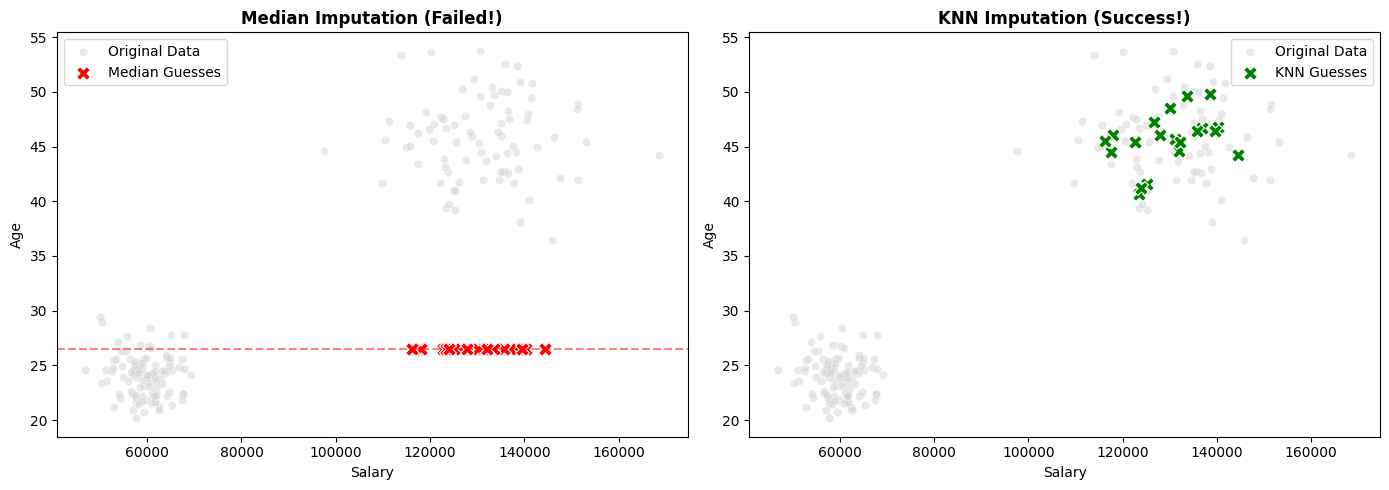

In [14]:
# Visualization
# Isolate just the rows where data was missing so we can see what the computers guessed
imputed_rows = df.loc[missing_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Median Imputation
sns.scatterplot(data=df, x='Salary', y='Age', color='lightgrey', alpha=0.5, ax=axes[0], label='Original Data')
sns.scatterplot(data=imputed_rows, x='Salary', y='Age_Median', color='red', s=100, marker='X', ax=axes[0], label='Median Guesses')
axes[0].set_title('Median Imputation (Failed!)', fontweight='bold')
axes[0].axhline(df['Age'].median(), color='red', linestyle='--', alpha=0.5)

# Plot B: KNN Imputation
sns.scatterplot(data=df, x='Salary', y='Age', color='lightgrey', alpha=0.5, ax=axes[1], label='Original Data')
sns.scatterplot(data=imputed_rows, x='Salary', y='Age_KNN', color='green', s=100, marker='X', ax=axes[1], label='KNN Guesses')
axes[1].set_title('KNN Imputation (Success!)', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# 5. THE NUMBERS
# ==========================================
print("--- Average Age Guessed for Missing Seniors ---")
print(f"What Median guessed: {imputed_rows['Age_Median'].mean():.1f} years old (Way too low!)")
print(f"What KNN guessed:    {imputed_rows['Age_KNN'].mean():.1f} years old (Perfectly accurate!)")

--- Average Age Guessed for Missing Seniors ---
What Median guessed: 26.5 years old (Way too low!)
What KNN guessed:    45.6 years old (Perfectly accurate!)


When i run the code, look at the two graphs.

- The Red Graph (Median): The imputer looked at the missing Senior Devs and dragged all of their ages down to ~34 (the company median). It placed them floating in the middle of nowhere, completely breaking the correlation between Age and Salary.

- The Green Graph (KNN): The imputer looked at the missing Senior Devs, noticed they all made ~$130k, found the 5 closest people to them (other Seniors), and perfectly placed their ages right back into the Senior cluster!